<a href="https://colab.research.google.com/github/Angi03/time_series/blob/main/4_garch%2Bevent_study.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# https://bashtage.github.io/arch/index.html
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("darkgrid")
plt.rc("figure", figsize=(16, 6))
plt.rc("savefig", dpi=90)
plt.rc("font", family="sans-serif")
plt.rc("font", size=14)

ARCH models are a popular class of volatility models that use observed values of returns or residuals as volatility shocks. A basic GARCH model is specified as

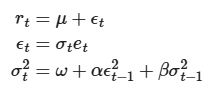

A complete ARCH model is divided into three components:


*  a mean model, e.g., a constant mean or an ARX;
*   a volatility process, e.g., a GARCH or an EGARCH process; and

*   a distribution for the standardized residuals.

In most applications, the simplest method to construct this model is to use the constructor function arch_model()

In [6]:
pip install arch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.3/981.3 kB 26.1 MB/s eta 0:00:00


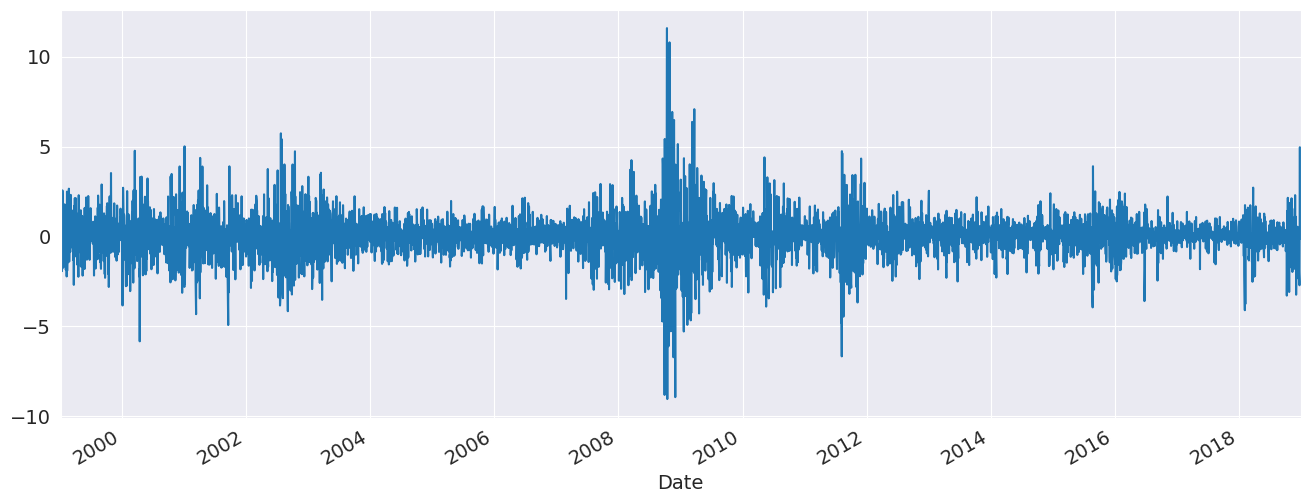

In [7]:
import datetime as dt

import arch.data.sp500

st = dt.datetime(1988, 1, 1)
en = dt.datetime(2018, 1, 1)
data = arch.data.sp500.load()
market = data["Adj Close"]
returns = 100 * market.pct_change().dropna()
ax = returns.plot()
xlim = ax.set_xlim(returns.index.min(), returns.index.max())

The simplest way to specify a model is to use the model constructor arch.arch_model which can specify most common models. The simplest invocation of arch will return a model with a constant mean, GARCH(1,1) volatility process and normally distributed errors.

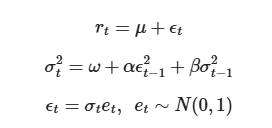

The model is estimated by calling fit. The optional inputs iter controls the frequency of output form the optimizer, and disp controls whether convergence information is returned. The results class returned offers direct access to the estimated parameters and related quantities, as well as a summary of the estimation results.

# GARCH Model with a Constant Mean

The **GARCH model with a constant mean** is a cornerstone of financial econometrics for modeling time series that exhibit volatility clustering – periods of high volatility followed by calm periods – while assuming a stable unconditional mean. Below we outline its theoretical foundation, interpretation, and key properties.

---

## 1. Model Specification

The model comprises two equations: a mean equation and a variance equation.

**Mean equation (constant mean):**  
$$
y_t = \mu + \varepsilon_t,\quad \varepsilon_t = \sigma_t z_t,
$$  
where  
- $y_t$ is the observed time series (e.g., asset returns),  
- $\mu$ is the constant conditional mean (also the unconditional mean, provided the process is covariance stationary),  
- $\varepsilon_t$ is the zero‑mean innovation,  
- $\sigma_t^2$ is the conditional variance of $\varepsilon_t$ given information up to time $t-1$,  
- $z_t$ is an i.i.d. process with $\mathbb{E}[z_t]=0$ and $\mathbb{E}[z_t^2]=1$. Common distributions for $z_t$ are the standard normal or the standardized Student’s $t$.

**Variance equation (GARCH(1,1)):**  
$$
\sigma_t^2 = \omega + \alpha \varepsilon_{t-1}^2 + \beta \sigma_{t-1}^2,
$$  
with the parameter restrictions  
$$
\omega > 0,\quad \alpha \ge 0,\quad \beta \ge 0,\quad \alpha + \beta < 1.
$$  
The condition $\alpha+\beta<1$ ensures covariance stationarity and a finite unconditional variance.

The GARCH(1,1) can be extended to GARCH($p,q$):  
$$
\sigma_t^2 = \omega + \sum_{i=1}^{q} \alpha_i \varepsilon_{t-i}^2 + \sum_{j=1}^{p} \beta_j \sigma_{t-j}^2,
$$  
with analogous non‑negativity and stationarity constraints.

---

## 2. Interpretation of Parameters

- **$\mu$ (constant mean):** Represents the long‑run average level of the series. In financial returns, $\mu$ is often close to zero but can capture a small drift.  
- **$\omega$ (baseline volatility):** The component of volatility that is independent of past news. The unconditional variance is $\mathbb{E}[\varepsilon_t^2] = \omega / (1 - \alpha - \beta)$. Thus $\omega$ determines the long‑run average volatility level once scaled by $1-\alpha-\beta$.  
- **$\alpha$ (ARCH or “news” coefficient):** Measures the sensitivity of current volatility to the most recent squared shock ($\varepsilon_{t-1}^2$). A high $\alpha$ means that a large (positive or negative) return immediately increases tomorrow’s volatility – the market reacts strongly to new information.  
- **$\beta$ (GARCH or “persistence” coefficient):** Captures the persistence of volatility. A high $\beta$ implies that volatility decays slowly; shocks have long‑lasting effects.  
- **$\alpha + \beta$ (persistence measure):** The sum determines the speed at which volatility mean‑reverts to its long‑run level. Values close to 1 indicate high persistence (e.g., daily financial returns often have $\alpha+\beta \approx 0.97$–0.99). When $\alpha+\beta = 1$, the process becomes an **integrated GARCH (IGARCH)** with no finite unconditional variance.

---

## 3. Theoretical Properties

- **Volatility clustering:** Because $\sigma_t^2$ depends positively on past squared innovations and past variances, large (small) shocks tend to be followed by large (small) shocks.  
- **Unconditional distribution:** Even if $z_t$ is Gaussian, the unconditional distribution of $\varepsilon_t$ (and hence $y_t$) has fatter tails than the normal due to the mixing of variances.  
- **Stationarity:** Under $\alpha+\beta < 1$, $\{\varepsilon_t\}$ is covariance stationary with $\mathbb{E}[\varepsilon_t^2] = \omega/(1-\alpha-\beta)$. The process for $\varepsilon_t^2$ follows an ARMA(1,1) representation:  
  $$
  \varepsilon_t^2 = \omega + (\alpha+\beta)\varepsilon_{t-1}^2 + u_t - \beta u_{t-1},
  $$  
  where $u_t = \varepsilon_t^2 - \sigma_t^2$ is a martingale difference sequence.  
- **Forecasting:** The conditional variance forecast for $h$ steps ahead converges to the unconditional variance at rate $(\alpha+\beta)^h$.

In [8]:
from arch import arch_model

am = arch_model(returns)
res = am.fit(update_freq=5)
print(res.summary())

Iteration:      5,   Func. Count:     35,   Neg. LLF: 6970.284960008103
Iteration:     10,   Func. Count:     63,   Neg. LLF: 6936.718477484757
Optimization terminated successfully    (Exit mode 0)
            Current function value: 6936.718476988985
            Iterations: 11
            Function evaluations: 68
            Gradient evaluations: 11
                     Constant Mean - GARCH Model Results                      
Dep. Variable:              Adj Close   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -6936.72
Distribution:                  Normal   AIC:                           13881.4
Method:            Maximum Likelihood   BIC:                           13907.5
                                        No. Observations:                 5030
Date:                Thu, Mar 19 2026   Df Residuals:                     5029
Time:          

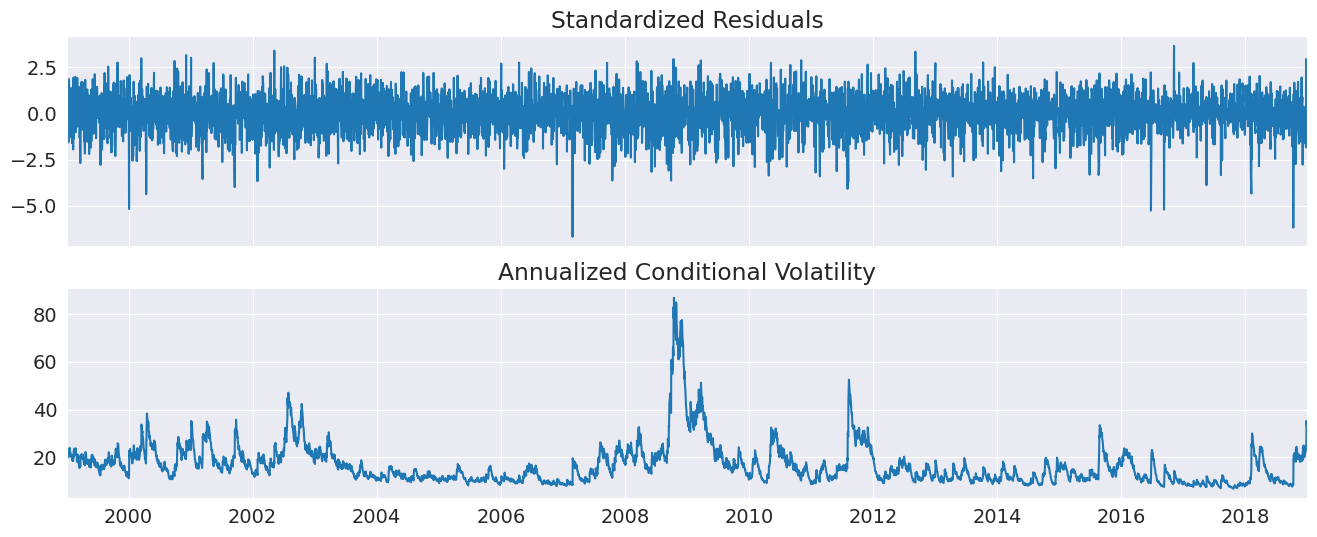

In [9]:
fig = res.plot(annualize="D")

# GJR-GARCH Model (with Asymmetric Volatility)

The **GJR-GARCH model** (Glosten, Jagannathan, and Runkle, 1993) extends the standard GARCH model by allowing positive and negative shocks to have asymmetric effects on volatility. This captures the **leverage effect** commonly observed in financial markets, where negative returns tend to increase future volatility more than positive returns of the same magnitude.

Below we outline its theoretical foundation, interpretation, and key properties, following the same structure as the constant mean GARCH explanation.

---

## 1. Model Specification

The model comprises two equations: a mean equation and a variance equation. The mean equation is typically the same as in standard GARCH (often a constant mean), while the variance equation includes an additional asymmetric term.

**Mean equation (constant mean):**  
$$
y_t = \mu + \varepsilon_t,\quad \varepsilon_t = \sigma_t z_t,
$$  
where  
- $y_t$ is the observed time series (e.g., asset returns),  
- $\mu$ is the constant conditional mean,  
- $\varepsilon_t$ is the zero‑mean innovation,  
- $\sigma_t^2$ is the conditional variance of $\varepsilon_t$ given information up to time $t-1$,  
- $z_t$ is an i.i.d. process with $\mathbb{E}[z_t]=0$ and $\mathbb{E}[z_t^2]=1$ (e.g., standard normal or standardized Student's $t$).

**Variance equation (GJR-GARCH(1,1)):**  
$$
\sigma_t^2 = \omega + \alpha \varepsilon_{t-1}^2 + \gamma I_{[\varepsilon_{t-1} < 0]} \varepsilon_{t-1}^2 + \beta \sigma_{t-1}^2,
$$  
where  
- $I_{[\varepsilon_{t-1} < 0]}$ is an **indicator function** that equals 1 when $\varepsilon_{t-1} < 0$ (negative shock) and 0 otherwise,  
- $\gamma$ is the **asymmetry coefficient** measuring the additional impact of negative shocks.

The parameter restrictions are:  
$$
\omega > 0,\quad \alpha \ge 0,\quad \beta \ge 0,\quad \alpha + \gamma \ge 0,\quad \alpha + \beta + \frac{1}{2}\gamma < 1
$$  
(the last condition ensures covariance stationarity for symmetrically distributed innovations).

The GJR-GARCH(1,1) can be extended to GJR-GARCH($p,q$):  
$$
\sigma_t^2 = \omega + \sum_{i=1}^{q} \left( \alpha_i \varepsilon_{t-i}^2 + \gamma_i I_{[\varepsilon_{t-i} < 0]} \varepsilon_{t-i}^2 \right) + \sum_{j=1}^{p} \beta_j \sigma_{t-j}^2,
$$  
with analogous non‑negativity and stationarity constraints.

---

## 2. Interpretation of Parameters

- **$\mu$ (constant mean):** Same as in standard GARCH – the long‑run average level of the series.  
- **$\omega$ (baseline volatility):** The component of volatility independent of past news. The unconditional variance (under symmetry) is $\mathbb{E}[\varepsilon_t^2] = \omega / [1 - \alpha - \beta - (\gamma/2)]$.  
- **$\alpha$ (ARCH or "news" coefficient):** Measures the sensitivity of current volatility to the most recent **positive** squared shock ($\varepsilon_{t-1}^2$ when $\varepsilon_{t-1} \ge 0$).  
- **$\gamma$ (asymmetry or "leverage" coefficient):** Captures the **additional** impact of a negative shock. When $\gamma > 0$, negative shocks increase volatility more than positive shocks of the same magnitude. The total impact of a negative shock is $\alpha + \gamma$.  
- **$\beta$ (GARCH or "persistence" coefficient):** Same as in standard GARCH – captures the persistence of volatility from past variance.  
- **$\alpha + \beta + \frac{\gamma}{2}$ (persistence measure):** Under the assumption that shocks are symmetrically distributed, this sum determines the speed at which volatility mean‑reverts. Values close to 1 indicate high persistence. For the model to be covariance stationary, this sum must be less than 1.

---

## 3. Theoretical Properties

- **Asymmetric volatility (leverage effect):** Because $\gamma > 0$, negative returns produce a larger increase in future volatility than positive returns. This matches empirical observations in equity markets, where a price drop increases financial leverage and thus risk.  
- **Volatility clustering:** As in standard GARCH, large shocks (whether positive or negative) tend to be followed by large shocks, but the effect is magnified for negative shocks.  
- **Unconditional distribution:** The unconditional distribution remains fat‑tailed, and the asymmetry in variance dynamics can generate additional skewness in returns.  
- **Stationarity:** Under $\alpha + \beta + \frac{\gamma}{2} < 1$ and symmetry of $z_t$, the process $\{\varepsilon_t\}$ is covariance stationary with finite unconditional variance.  
- **News impact curve:** The relationship between $\varepsilon_{t-1}$ and $\sigma_t^2$ is piecewise quadratic:  
  $$
  \sigma_t^2 = \omega + \beta \sigma_{t-1}^2 + \begin{cases}
  \alpha \varepsilon_{t-1}^2 & \text{if } \varepsilon_{t-1} \ge 0 \\
  (\alpha + \gamma) \varepsilon_{t-1}^2 & \text{if } \varepsilon_{t-1} < 0
  \end{cases}
  $$  
  This creates a kink at zero, with a steeper slope on the negative side when $\gamma > 0$.

---

In [10]:
am = arch_model(returns, p=1, o=1, q=1)
res = am.fit(update_freq=5, disp="off")
print(res.summary())

                   Constant Mean - GJR-GARCH Model Results                    
Dep. Variable:              Adj Close   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                  GJR-GARCH   Log-Likelihood:               -6822.88
Distribution:                  Normal   AIC:                           13655.8
Method:            Maximum Likelihood   BIC:                           13688.4
                                        No. Observations:                 5030
Date:                Thu, Mar 19 2026   Df Residuals:                     5029
Time:                        14:48:31   Df Model:                            1
                                  Mean Model                                 
                 coef    std err          t      P>|t|       95.0% Conf. Int.
-----------------------------------------------------------------------------
mu             0.0175  1.145e-02      1.529      0.126 

# TARCH/ZARCH Model (with Asymmetric Absolute Value Effects)

The **TARCH model** (Threshold ARCH), also known as **ZARCH** (Zakoian ARCH, 1994), models volatility using absolute values rather than squares. This approach allows for asymmetric effects of positive and negative shocks directly on the conditional standard deviation, which can be more natural for certain financial applications. The model captures the leverage effect through a threshold term in the absolute value equation.

Below we outline its theoretical foundation, interpretation, and key properties, following the same structure as the previous GARCH and GJR-GARCH explanations.

---

## 1. Model Specification

The model comprises two equations: a mean equation and a volatility equation. The volatility process models the conditional standard deviation (or variance raised to a power) using absolute values of past shocks.

**Mean equation (constant mean):**  
$$
y_t = \mu + \varepsilon_t,\quad \varepsilon_t = \sigma_t z_t,
$$  
where  
- $y_t$ is the observed time series (e.g., asset returns),  
- $\mu$ is the constant conditional mean,  
- $\varepsilon_t$ is the zero‑mean innovation,  
- $\sigma_t$ is the conditional standard deviation (or volatility) of $\varepsilon_t$ given information up to time $t-1$,  
- $z_t$ is an i.i.d. process with $\mathbb{E}[z_t]=0$ and $\mathbb{E}[z_t^2]=1$ (e.g., standard normal or standardized Student's $t$).

**Volatility equation (TARCH/ZARCH):**  

The general form for a TARCH model of order (1,1) with power $\delta$ is:
$$
\sigma_t^\delta = \omega + \alpha |\varepsilon_{t-1}|^\delta + \gamma I_{[\varepsilon_{t-1} < 0]} |\varepsilon_{t-1}|^\delta + \beta \sigma_{t-1}^\delta,
$$  
where  
- $\delta > 0$ is the **power parameter** (often set to 1 for standard TARCH, or 2 for standard GARCH),  
- $I_{[\varepsilon_{t-1} < 0]}$ is an **indicator function** that equals 1 when $\varepsilon_{t-1} < 0$ (negative shock) and 0 otherwise,  
- $\gamma$ is the **asymmetry coefficient** measuring the additional impact of negative shocks on the conditional standard deviation (or volatility raised to power $\delta$).

**Special case: TARCH(1,1) with $\delta = 1$ (standard TARCH/ZARCH):**  
$$
\sigma_t = \omega + \alpha |\varepsilon_{t-1}| + \gamma I_{[\varepsilon_{t-1} < 0]} |\varepsilon_{t-1}| + \beta \sigma_{t-1}.
$$  
This models the conditional **standard deviation** directly as a linear function of past absolute shocks, with an additional term for negative shocks.

The parameter restrictions for $\delta = 1$ are typically:  
$$
\omega > 0,\quad \alpha \ge 0,\quad \beta \ge 0,\quad \alpha + \gamma \ge 0,\quad \alpha + \beta + \frac{1}{2}\gamma < 1
$$  
(the last condition ensures covariance stationarity for symmetrically distributed innovations).

The TARCH model can be extended to higher orders:  
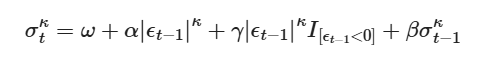
with analogous non‑negativity and stationarity constraints depending on $\delta$ and the distribution of $z_t$.

---

## 2. Interpretation of Parameters

- **$\mu$ (constant mean):** Same as in standard GARCH – the long‑run average level of the series.  
- **$\delta$ (power parameter):** Determines the transformation of volatility being modeled.  
  - $\delta = 1$: Models conditional **standard deviation** (TARCH/ZARCH).  
  - $\delta = 2$: Models conditional **variance** (equivalent to GJR-GARCH with absolute values).  
  - Other values allow flexible power transformations.  
- **$\omega$ (baseline volatility):** The component of volatility (in power $\delta$ units) independent of past news.  
- **$\alpha$ (ARCH or "news" coefficient):** Measures the sensitivity of current volatility (raised to power $\delta$) to the most recent **positive** absolute shock ($|\varepsilon_{t-1}|^\delta$ when $\varepsilon_{t-1} \ge 0$).  
- **$\gamma$ (asymmetry or "leverage" coefficient):** Captures the **additional** impact of a negative shock. When $\gamma > 0$, negative shocks increase volatility more than positive shocks of the same magnitude. The total impact of a negative shock is $\alpha + \gamma$.  
- **$\beta$ (TARCH or "persistence" coefficient):** Captures the persistence of volatility – how much of past volatility (in power $\delta$ units) carries over to the current period.

For $\delta = 1$, the coefficients are directly interpretable in units of **standard deviation** (not variance), which can be more intuitive for some applications.

---

## 3. Theoretical Properties

- **Asymmetric volatility (leverage effect):** When $\gamma > 0$, negative shocks produce a larger increase in future volatility than positive shocks, consistent with empirical evidence. The asymmetry acts directly on the conditional standard deviation (for $\delta = 1$).  
- **Volatility clustering:** As in standard GARCH, large absolute shocks (whether positive or negative) tend to be followed by high volatility, but the effect is stronger for negative shocks.  
- **Absolute value specification:** Using absolute values instead of squares can make the model more robust to extreme observations, as it reduces the influence of very large shocks.  
- **Stationarity:** For $\delta = 1$ and symmetric innovations, the condition $\alpha + \beta + \frac{\gamma}{2} < 1$ ensures covariance stationarity. The process for $\sigma_t$ is stationary and mean-reverting.  
- **News impact curve:** For $\delta = 1$, the relationship between $\varepsilon_{t-1}$ and $\sigma_t$ is piecewise linear:  
  $$
  \sigma_t = \omega + \beta \sigma_{t-1} + \begin{cases}
  \alpha |\varepsilon_{t-1}| & \text{if } \varepsilon_{t-1} \ge 0 \\
  (\alpha + \gamma) |\varepsilon_{t-1}| & \text{if } \varepsilon_{t-1} < 0
  \end{cases}
  $$  
  This creates a V-shaped (rather than U-shaped) response, with a steeper slope on the negative side when $\gamma > 0$.

---

In [11]:
am = arch_model(returns, p=1, o=1, q=1, power=1.0)
res = am.fit(update_freq=5)
print(res.summary())

Iteration:      5,   Func. Count:     45,   Neg. LLF: 6829.2531610519045
Iteration:     10,   Func. Count:     79,   Neg. LLF: 6799.17861626466
Optimization terminated successfully    (Exit mode 0)
            Current function value: 6799.178524134302
            Iterations: 15
            Function evaluations: 109
            Gradient evaluations: 14
                  Constant Mean - TARCH/ZARCH Model Results                   
Dep. Variable:              Adj Close   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                TARCH/ZARCH   Log-Likelihood:               -6799.18
Distribution:                  Normal   AIC:                           13608.4
Method:            Maximum Likelihood   BIC:                           13641.0
                                        No. Observations:                 5030
Date:                Thu, Mar 19 2026   Df Residuals:                     5029
Time:         

# Event Study Analysis: Theory and Methodology

**Event study analysis** is a statistical methodology used to assess the impact of a specific event on the value of a firm or financial security. Rooted in the efficient market hypothesis, event studies examine whether there are "abnormal" returns around the time of the event—returns that deviate from what would be expected in the absence of the event .

Originally developed by Ray Ball and Philip Brown (1968) and Eugene Fama et al. (1969) in corporate finance, event studies have become one of the most important methodological approaches in empirical finance and accounting research . They are widely used to test market efficiency, evaluate corporate decisions (mergers, earnings announcements, stock splits), and assess the impact of macroeconomic events or regulatory changes .

Below we outline the theoretical foundation, methodological steps, interpretation, and key considerations of event study analysis.

---

## 1. Core Concepts and Theoretical Foundation

### 1.1 The Efficient Market Hypothesis (EMH)

Event study methodology relies on the assumption of **market efficiency**, particularly semi-strong form efficiency . Under this assumption:
- All publicly available information is immediately reflected in security prices
- The impact of an event should be captured in prices within a short window around the event
- Price changes following the event reflect the economic significance of the news

If markets are efficient, measuring the **abnormal return**—the difference between actual returns and expected returns in the absence of the event—provides an unbiased estimate of the event's economic impact .

### 1.2 Potential Outcomes Framework

In modern causal inference terms, event studies aim to estimate the **treatment effect** of an event on security returns. For each security $i$ at time $t$, we define :

- $R_{it}(1)$: Potential return if the event occurs
- $R_{it}(0)$: Potential return if the event does not occur

The treatment effect for security $i$ at time $t$ is:
$$
\tau_{it} = R_{it}(1) - R_{it}(0)
$$

The fundamental problem of causal inference is that we only observe $R_{it}(1)$ for event periods and $R_{it}(0)$ for non-event periods. Event study methodology constructs a **counterfactual**—an estimate of what returns would have been absent the event—using asset pricing models .

---

## 2. Model Specification and Key Parameters

### 2.1 Defining the Timeline

Every event study requires defining three key time windows :

| Window | Definition | Purpose |
|--------|------------|---------|
| **Estimation Window** | Period before the event (e.g., $t_{-250}$ to $t_{-10}$) | Estimate normal return model parameters |
| **Event Window** | Period surrounding the event (e.g., $t_{-1}$ to $t_{+1}$) | Capture the event's impact |
| **Post-Event Window** | Period after the event (optional) | Examine long-term effects |

The **event date** ($t_0$) is the day the event becomes publicly known. The event window is often expanded to include $t_{-1}$ and $t_{+1}$ to capture:
- Anticipation effects (leakage before announcement)
- Delayed reactions (after-market close announcements)

### 2.2 Measuring Normal Returns

Normal returns are the expected returns if the event had not occurred. Several approaches exist :

#### 2.2.1 Statistical Models

**Constant Mean Return Model:**
$$
R_{it} = \mu_i + \varepsilon_{it},\quad \mathbb{E}[\varepsilon_{it}] = 0
$$
Assumes expected return is constant over time .

**Market Model (Single-Index Model):**
$$
R_{it} = \alpha_i + \beta_i R_{mt} + \varepsilon_{it}
$$
where $R_{mt}$ is the market return. This model improves over the constant mean by removing the portion of return related to market movements, reducing variance and increasing detection power .

#### 2.2.2 Economic Models

**Capital Asset Pricing Model (CAPM):**
$$
\mathbb{E}[R_{it}] = R_{ft} + \beta_i(\mathbb{E}[R_{mt}] - R_{ft})
$$
where $R_{ft}$ is the risk-free rate .

**Fama-French Three-Factor Model:**
$$
R_{it} - R_{ft} = \alpha_i + \beta_i(R_{mt} - R_{ft}) + s_i SMB_t + h_i HML_t + \varepsilon_{it}
$$
where SMB (Small Minus Big) captures size effects and HML (High Minus Low) captures value effects .

**Carhart Four-Factor Model:**
Adds a momentum factor (UMD) to the Fama-French model :
$$
R_{it} - R_{ft} = \alpha_i + \beta_i(R_{mt} - R_{ft}) + s_i SMB_t + h_i HML_t + u_i UMD_t + \varepsilon_{it}
$$

#### 2.2.3 Market-Adjusted Model

A simplified approach assuming $\alpha_i = 0$ and $\beta_i = 1$ for all securities:
$$
R_{it} = R_{mt} + \varepsilon_{it}
$$
This requires no estimation period but may be less accurate .

### 2.3 Measuring Abnormal Returns

**Abnormal Return (AR):** The difference between actual and normal returns :
$$
AR_{it} = R_{it} - \mathbb{E}[R_{it} | X_t]
$$
where $X_t$ represents conditioning information (e.g., market returns).

For the market model:
$$
AR_{it} = R_{it} - (\hat{\alpha}_i + \hat{\beta}_i R_{mt})
$$
where $\hat{\alpha}_i$ and $\hat{\beta}_i$ are estimated from the estimation window .

---

## 3. Aggregation of Abnormal Returns

### 3.1 Aggregation Across Time for a Single Security

**Cumulative Abnormal Return (CAR):** Sum of abnormal returns over the event window :
$$
CAR_i(t_1, t_2) = \sum_{t=t_1}^{t_2} AR_{it}
$$

For the market model, under the null hypothesis of no abnormal returns:
$$
\mathbb{E}[CAR_i(t_1, t_2)] = 0
$$
$$
Var(CAR_i(t_1, t_2)) = \sigma_i^2(t_2 - t_1 + 1)
$$
where $\sigma_i^2$ is the variance of the estimation window residuals .

### 3.2 Aggregation Across Securities

**Average Abnormal Return (AAR):** Cross-sectional average of abnormal returns at time $t$ :
$$
AAR_t = \frac{1}{N} \sum_{i=1}^{N} AR_{it}
$$

**Cumulative Average Abnormal Return (CAAR):** Average CAR across securities :
$$
CAAR(t_1, t_2) = \frac{1}{N} \sum_{i=1}^{N} CAR_i(t_1, t_2) = \sum_{t=t_1}^{t_2} AAR_t
$$

---

In [39]:
pip install eventstudy
# https://lemairejean-baptiste.github.io/eventstudy/index.html

In [14]:
#import eventstudy as es
import numpy as np
import matplotlib.pyplot as plt

In [18]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [23]:
es.Single.import_returns('/content/drive/MyDrive/Financial econometrics V2.0/returns_GAFAM.csv')
es.Single.import_FamaFrench('/content/drive/MyDrive/Financial econometrics V2.0/famafrench.csv')

##Example 1: A single event

As an introductory example, we will compute the event study analysis of the announcement of the first iphone, made by Steve Jobs during MacWorld exhibition, on January 7, 2007.

Run the event study, here using the Fama-French 3-factor model:

In [27]:
event = es.Single.FamaFrench_3factor(
    security_ticker = 'AAPL',
    event_date = np.datetime64('2007-01-07'),
    event_window = (-2,+10),
    estimation_size = 300,
    buffer_size = 30
)

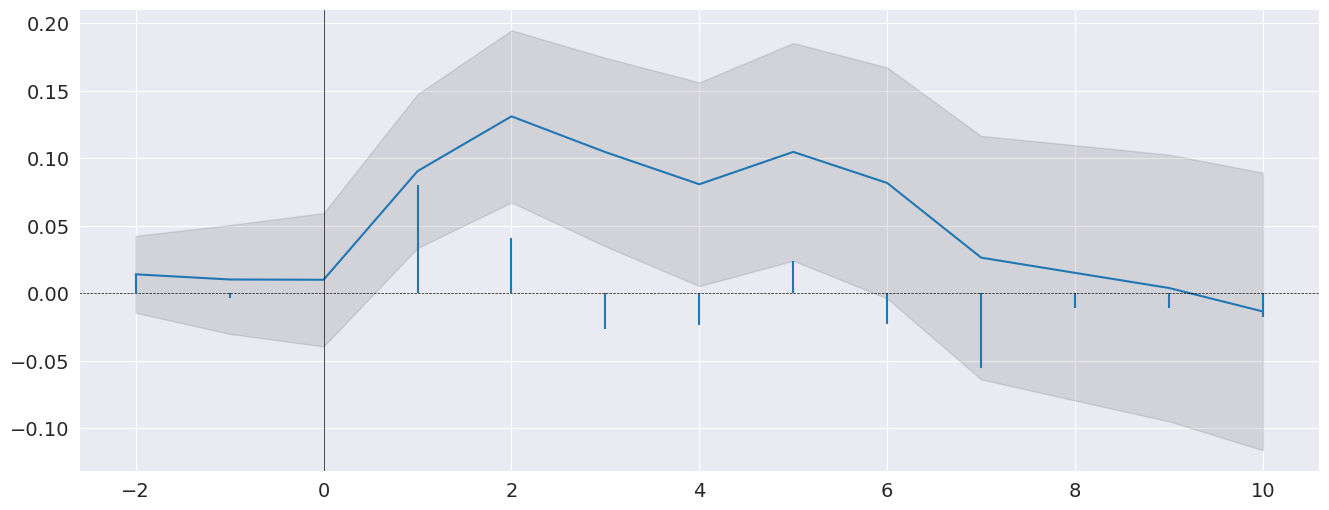

In [28]:
event.plot(AR=True)
plt.show() # use standard matplotlib function to display the plot

In [29]:
event.results(decimals=[3,5,3,5,2,2])

,AR,Std. E. AR,CAR,Std. E. CAR,T-stat,P-value
-2,0.014,0.02219,0.014,0.02219,0.63,0.53
-1,-0.004,0.02219,0.01,0.03138,0.32,0.75
0,-0.000,0.02219,0.01,0.03844,0.26,0.80
1,0.080,0.02219,0.09 **,0.04438,2.04,0.04
2,0.041,0.02219,0.131 **,0.04962,2.64,0.01
3,-0.026,0.02219,0.104 *,0.05436,1.92,0.06
4,-0.024,0.02219,0.081,0.05871,1.37,0.17
5,0.024,0.02219,0.105,0.06277,1.67,0.10
6,-0.023,0.02219,0.082,0.06658,1.23,0.22
7,-0.055,0.02219,0.026,0.07018,0.37,0.71


Note

Asterisks are added automatically to highlight the level of significance (Significance level: *** at 99%, ** at 95%, * at 90%). You can remove asterisks by setting asterisks parameter at False.

decimals is a list of integer setting for each column (except index) the rounding decimal. You can also set one integer (e.g. decimals = 3) if you want all columns to be rounded the same.

##Example 2: Multiple events

The eventstudy package offer three different entry points. The list of events can be provided using a csv file, a plain python text or a python list.

In this second example, based on the same data and preliminary work, we will compute an event study on GAFA annual report (10-K form) releases.

Data preparation
The first step is to gather the data about the events and to format it. For the purpose of this example we will use the csv file methods. The csv file must contains all information needed to compute the model.

The event study will be computed using the market model. According to the (/api/eventstudy.Single.market_model.html#eventstudy.Single.market_model)[API documentation] aside from event study parameters which will be set globally for all events (event_window, estimation_size and buffer_size), the market model needs the security_ticker, the market_ticker and the event_date parameters.

Thus, the csv file should contain three columns with the exact same names as the parameter names.

To create an event study analysis of an aggregate of events, we will use the Multiple class. This class is designed following the same spirit and structure of the Single class.

Run the event study using the csv importer method:

In [31]:
release_10K = es.Multiple.from_csv(
    path = '/content/drive/MyDrive/Financial econometrics V2.0/10K.csv', # the path to the csv file created
    event_study_model = es.Single.market_model,
    event_window = (-5,+10),
    estimation_size = 200,
    buffer_size = 30,
    date_format = '%d/%m/%Y',
    ignore_errors = True
)

Tips: Get more details on errors by calling Multiple.error_report() method or by exploring Multiple.errors class variable.


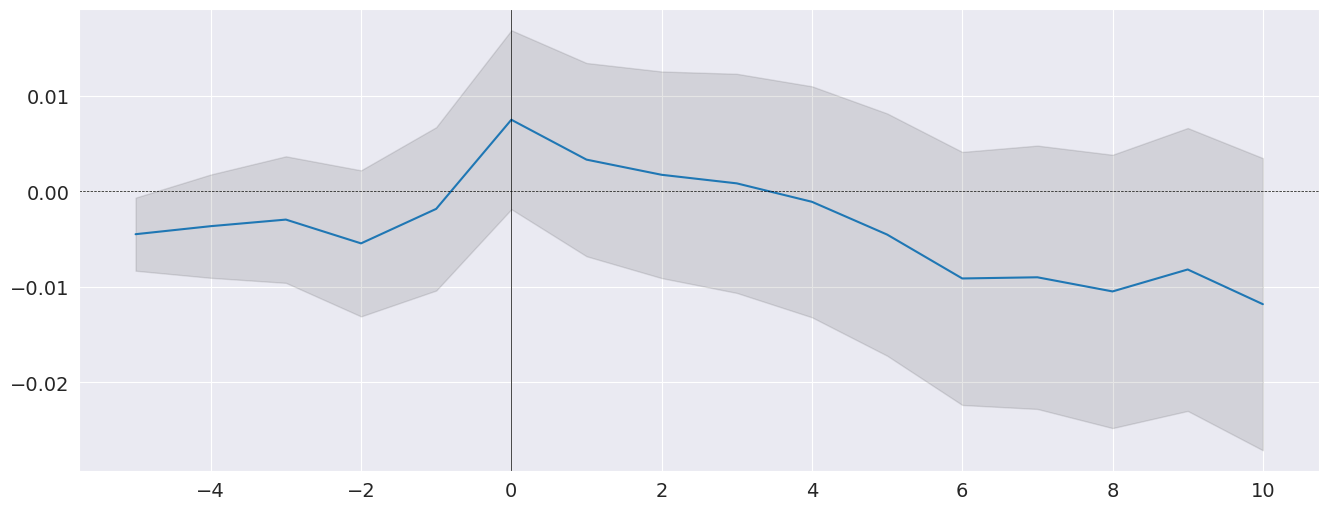

In [32]:
release_10K.plot(confidence=.95)
plt.show() # use standard matplotlib function to display the plot

In [33]:
release_10K.results(decimals=[3,5,3,5,2,2])

,AAR,Std. E. AAR,CAAR,Std. E. CAAR,T-stat,P-value
-5,-0.004,0.00233,-0.004 *,0.00233,-1.93,0.05
-4,0.001,0.00233,-0.004,0.00329,-1.11,0.27
-3,0.001,0.00233,-0.003,0.00403,-0.73,0.46
-2,-0.002,0.00233,-0.005,0.00465,-1.17,0.24
-1,0.004,0.00233,-0.002,0.00520,-0.35,0.72
0,0.009,0.00233,0.008,0.00570,1.32,0.19
1,-0.004,0.00233,0.003,0.00615,0.54,0.59
2,-0.002,0.00233,0.002,0.00658,0.26,0.79
3,-0.001,0.00233,0.001,0.00698,0.12,0.90
4,-0.002,0.00233,-0.001,0.00735,-0.15,0.88


In [34]:
release_10K.get_CAR_dist(4)

,Mean,Variance,Kurtosis,Skewness,Min,Quantile 25%,Quantile 50%,Quantile 75%,Max
-5,-0.0045,0.0003,0.7574,-0.2714,-0.0466,-0.0109,-0.0048,0.0045,0.0372
-4,-0.0036,0.0006,-0.1199,-0.3267,-0.0600,-0.0147,0.0004,0.0069,0.0507
-3,-0.0030,0.0009,0.1443,-0.1972,-0.0843,-0.0229,-0.0047,0.0173,0.0617
-2,-0.0054,0.0007,-0.0016,0.2398,-0.0637,-0.0212,-0.0074,0.0064,0.0553
-1,-0.0018,0.0012,0.3359,0.4938,-0.0693,-0.0227,-0.0082,0.0139,0.0915
0,0.0075,0.0036,1.5656,1.1312,-0.1044,-0.0285,-0.0014,0.0253,0.2007
1,0.0033,0.0044,1.0385,1.0417,-0.1013,-0.0370,-0.0125,0.0236,0.2110
2,0.0017,0.0049,0.2146,0.9171,-0.0948,-0.0419,-0.0153,0.0323,0.1875
3,0.0008,0.0052,0.4870,0.9131,-0.1281,-0.0448,-0.0190,0.0296,0.1981
4,-0.0011,0.0051,0.6812,0.9303,-0.1233,-0.0410,-0.0192,0.0256,0.2090


##Bonus: Loop in event

The true strengh of this package is to use python. You can create complex algorithms to compute programatically event stuy analyses. From the same data as above, we will compute an event study of 10-K form releases for each company.

Data preparation
This time, we will use the eventstudy.Multiple.from_list method which set event list using a python list. This let the user manipulate the list of event before computing event studies.

This list must contains all parameters needed to compute the selected model (here we will use the Fama-French 3-factor model). The Fama-French factors’ data has to be set using the eventstudy.Single.import_FamaFrench method (see preliminary step).

In [35]:
events_db = [
    {'security_ticker': 'AAPL', 'market_ticker': 'SPY', 'event_date': np.datetime64('2019-10-31')},
    {'security_ticker': 'AAPL', 'market_ticker': 'SPY', 'event_date': np.datetime64('2018-11-05')},
    {'security_ticker': 'AAPL', 'market_ticker': 'SPY', 'event_date': np.datetime64('2017-11-03')},
    {'security_ticker': 'AAPL', 'market_ticker': 'SPY', 'event_date': np.datetime64('2016-10-26')},
    {'security_ticker': 'AAPL', 'market_ticker': 'SPY', 'event_date': np.datetime64('2015-10-28')},
    {'security_ticker': 'AAPL', 'market_ticker': 'SPY', 'event_date': np.datetime64('2014-10-27')},
    {'security_ticker': 'AAPL', 'market_ticker': 'SPY', 'event_date': np.datetime64('2013-10-30')},
    {'security_ticker': 'AAPL', 'market_ticker': 'SPY', 'event_date': np.datetime64('2012-10-31')},
    {'security_ticker': 'AAPL', 'market_ticker': 'SPY', 'event_date': np.datetime64('2011-10-26')},
    {'security_ticker': 'AAPL', 'market_ticker': 'SPY', 'event_date': np.datetime64('2010-10-27')},
    {'security_ticker': 'GOOG', 'market_ticker': 'SPY', 'event_date': np.datetime64('2020-02-04')},
    {'security_ticker': 'GOOG', 'market_ticker': 'SPY', 'event_date': np.datetime64('2019-02-05')},
    {'security_ticker': 'GOOG', 'market_ticker': 'SPY', 'event_date': np.datetime64('2018-02-06')},
    {'security_ticker': 'GOOG', 'market_ticker': 'SPY', 'event_date': np.datetime64('2017-02-03')},
    {'security_ticker': 'GOOG', 'market_ticker': 'SPY', 'event_date': np.datetime64('2016-02-11')},
    {'security_ticker': 'FB', 'market_ticker': 'SPY', 'event_date': np.datetime64('2020-01-30')},
    {'security_ticker': 'FB', 'market_ticker': 'SPY', 'event_date': np.datetime64('2019-01-31')},
    {'security_ticker': 'FB', 'market_ticker': 'SPY', 'event_date': np.datetime64('2018-02-01')},
    {'security_ticker': 'FB', 'market_ticker': 'SPY', 'event_date': np.datetime64('2016-01-28')},
    {'security_ticker': 'FB', 'market_ticker': 'SPY', 'event_date': np.datetime64('2015-01-29')},
    {'security_ticker': 'FB', 'market_ticker': 'SPY', 'event_date': np.datetime64('2014-01-31')},
    {'security_ticker': 'AMZN', 'market_ticker': 'SPY', 'event_date': np.datetime64('2020-01-31')},
    {'security_ticker': 'AMZN', 'market_ticker': 'SPY', 'event_date': np.datetime64('2019-02-01')},
    {'security_ticker': 'AMZN', 'market_ticker': 'SPY', 'event_date': np.datetime64('2018-02-02')},
    {'security_ticker': 'AMZN', 'market_ticker': 'SPY', 'event_date': np.datetime64('2017-02-10')},
    {'security_ticker': 'AMZN', 'market_ticker': 'SPY', 'event_date': np.datetime64('2016-01-29')},
    {'security_ticker': 'AMZN', 'market_ticker': 'SPY', 'event_date': np.datetime64('2015-01-30')},
    {'security_ticker': 'AMZN', 'market_ticker': 'SPY', 'event_date': np.datetime64('2013-01-30')},
    {'security_ticker': 'AMZN', 'market_ticker': 'SPY', 'event_date': np.datetime64('2012-02-01')},
    {'security_ticker': 'AMZN', 'market_ticker': 'SPY', 'event_date': np.datetime64('2011-01-28')},
    {'security_ticker': 'AMZN', 'market_ticker': 'SPY', 'event_date': np.datetime64('2010-01-29')},
    {'security_ticker': 'MSFT', 'market_ticker': 'SPY', 'event_date': np.datetime64('2019-08-01')},
    {'security_ticker': 'MSFT', 'market_ticker': 'SPY', 'event_date': np.datetime64('2018-08-03')},
    {'security_ticker': 'MSFT', 'market_ticker': 'SPY', 'event_date': np.datetime64('2017-08-02')},
    {'security_ticker': 'MSFT', 'market_ticker': 'SPY', 'event_date': np.datetime64('2016-07-28')},
    {'security_ticker': 'MSFT', 'market_ticker': 'SPY', 'event_date': np.datetime64('2015-07-31')},
    {'security_ticker': 'MSFT', 'market_ticker': 'SPY', 'event_date': np.datetime64('2014-07-31')},
    {'security_ticker': 'MSFT', 'market_ticker': 'SPY', 'event_date': np.datetime64('2013-07-30')},
    {'security_ticker': 'MSFT', 'market_ticker': 'SPY', 'event_date': np.datetime64('2012-07-26')},
    {'security_ticker': 'MSFT', 'market_ticker': 'SPY', 'event_date': np.datetime64('2011-07-28')},
    {'security_ticker': 'MSFT', 'market_ticker': 'SPY', 'event_date': np.datetime64('2010-07-30')}
]

Using a list comprehension, the full list of events can be filtered to create one list per company’s ticker. Then we can compute for each company, the event study using the Fama-French 3 factor model and store each event study in a releases dictionary.

In [36]:
tickers = ['GOOG', 'AAPL', 'FB', 'AMZN', 'MSFT']
releases = dict()

for ticker in tickers:
    events = [event for event in events_db if event['security_ticker']==ticker]

    releases[ticker] = es.Multiple.from_list(
        events,
        es.Single.FamaFrench_3factor,
        event_window= (-5,+10)
    )

Tips: Get more details on errors by calling Multiple.error_report() method or by exploring Multiple.errors class variable.
Tips: Get more details on errors by calling Multiple.error_report() method or by exploring Multiple.errors class variable.
Tips: Get more details on errors by calling Multiple.error_report() method or by exploring Multiple.errors class variable.
Tips: Get more details on errors by calling Multiple.error_report() method or by exploring Multiple.errors class variable.


GOOG


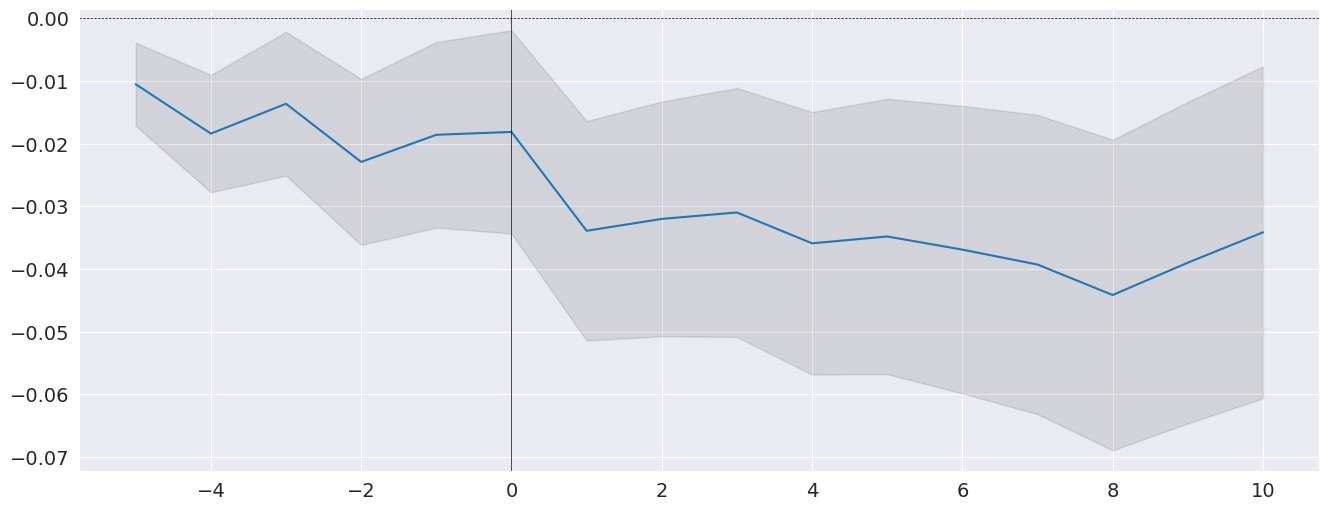

AAPL


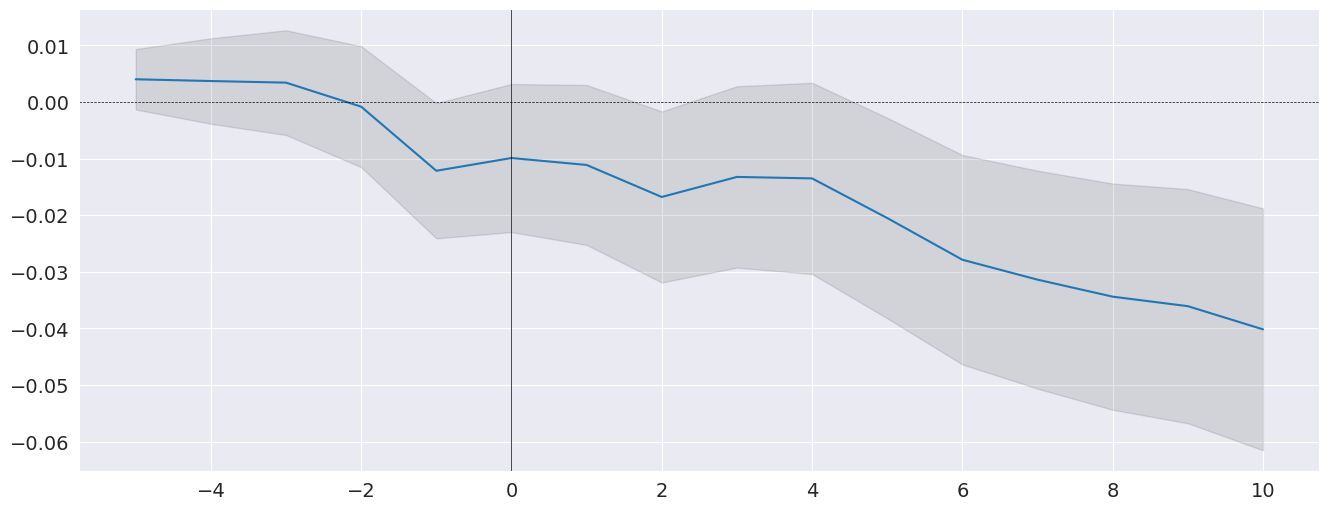

FB


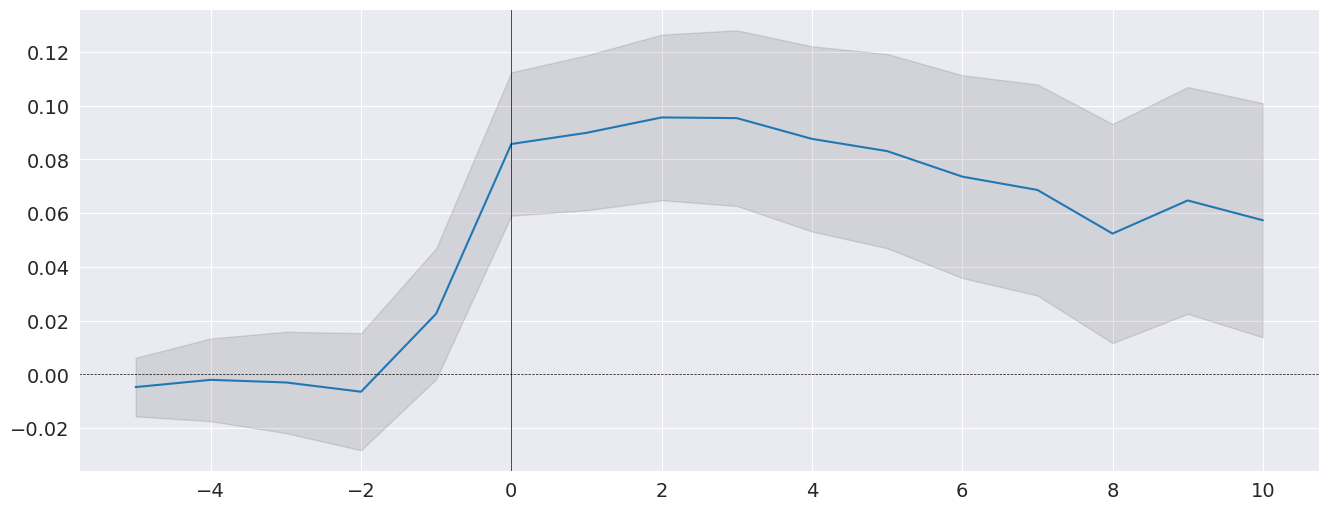

AMZN


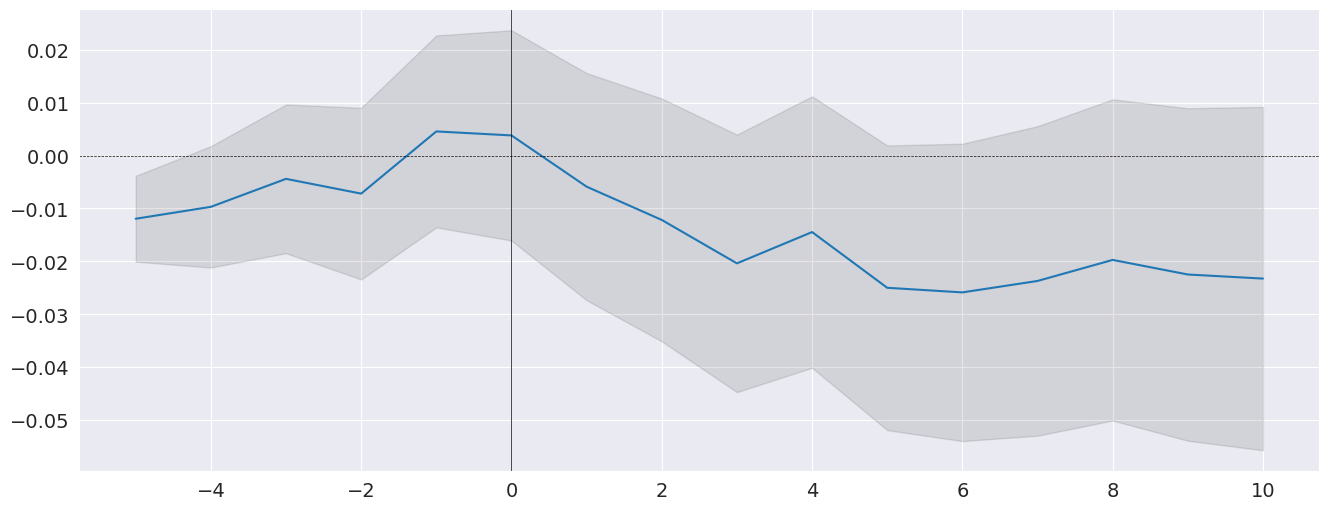

MSFT


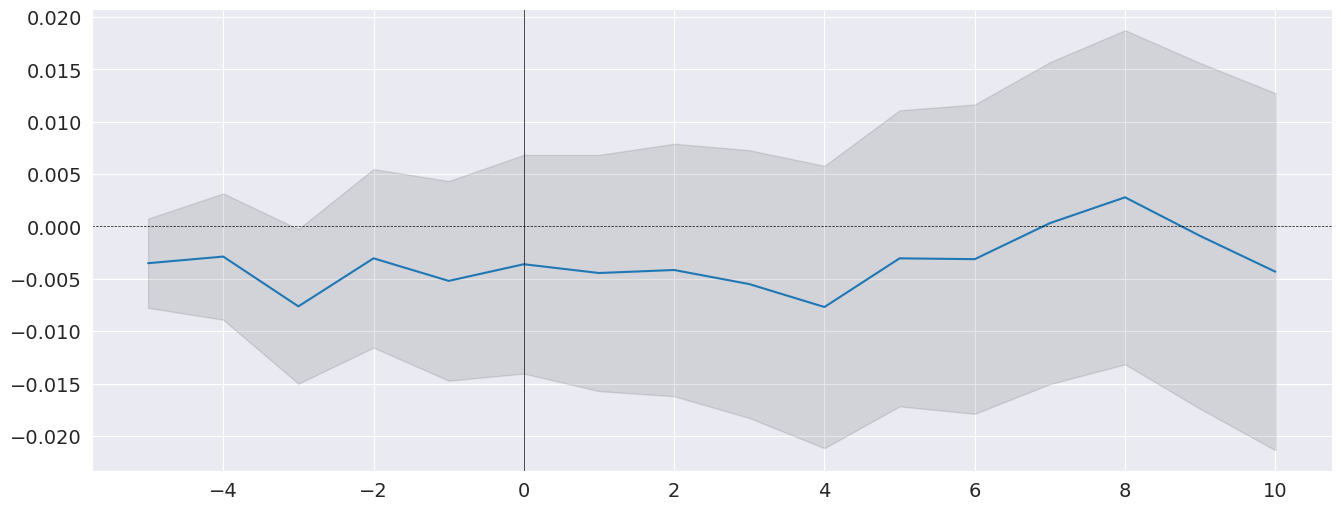

In [37]:
for ticker, event in releases.items():
    print(ticker)
    event.plot()
    plt.show()